In [1]:
# 1. Imports
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, accuracy_score, confusion_matrix
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

X = pd.read_csv("X_ready_for_modelling.csv")
y = pd.read_csv("y_ready_for_modelling.csv")


In [4]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [5]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
rf = RandomForestRegressor(n_estimators=300, random_state=42)

lr.fit(X_train, y_train)
rf.fit(X_train, y_train)

lr_pred = lr.predict(X_test)
rf_pred = rf.predict(X_test)


d:\Python\Lib\site-packages\sklearn\base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [6]:
lr_r2 = r2_score(y_test, lr_pred)
rf_r2 = r2_score(y_test, rf_pred)

if rf_r2 > lr_r2:
    best_pred = rf_pred
    model_name = "Random Forest"
else:
    best_pred = lr_pred
    model_name = "Linear Regression"

print("\nBest model:", model_name)



Best model: Linear Regression


In [ ]:

r2 = r2_score(y_test, best_pred)
rmse = np.sqrt(mean_squared_error(y_test, best_pred))

print("R2 Score:", r2)
print("RMSE:", rmse)


R2 Score: 0.9999162760118613
RMSE: 278.93895933840435


In [8]:

y_test_cls = (y_test.shift(-1) > y_test).astype(int)[:-1]
pred_cls = (pd.Series(best_pred).shift(-1) > pd.Series(best_pred)).astype(int)[:-1]

acc = accuracy_score(y_test_cls, pred_cls)
cm = confusion_matrix(y_test_cls, pred_cls)

print("\nAccuracy Score:", acc)
print("\nConfusion Matrix:\n", cm)


ValueError: Data must be 1-dimensional, got ndarray of shape (1177, 1) instead

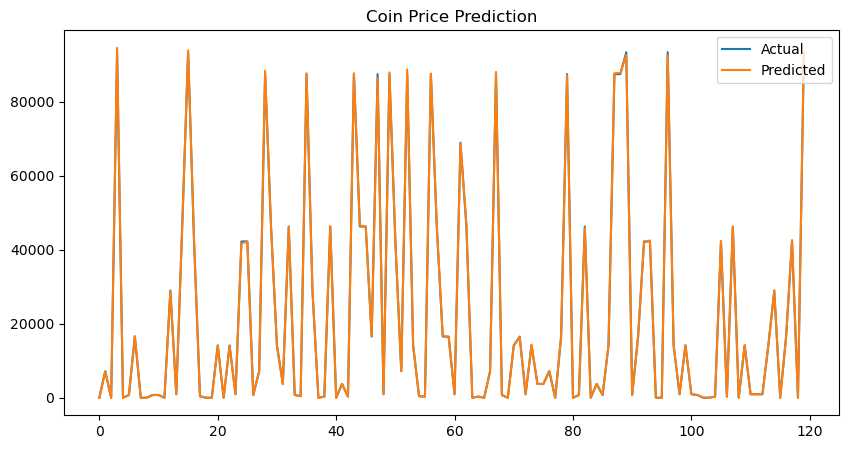

In [9]:

# ==========================================
# 12. Clear graph (few samples)
# ==========================================
samples = 120

plt.figure(figsize=(10,5))
plt.plot(y_test.values[-samples:], label="Actual")
plt.plot(best_pred[-samples:], label="Predicted")
plt.legend()
plt.title("Coin Price Prediction")
plt.show()